In [2]:
import pandas as pd

# Load from sheet named "CPI"
#cpi_df = pd.read_excel(r"C:\Users\dode6\Downloads\school\Graduation Project\Real work\CPI Final 1995 till 2024.xlsx", sheet_name="CPI", parse_dates=["Date"])
cpi_df = pd.read_csv(r"C:\Users\dode6\Downloads\school\Graduation Project\Real work\CPI IMF till sep 2024 - Sheet4.csv", parse_dates=["Date"])


# Load from sheet named "Exchange Rate"
exr_df = pd.read_excel(r"C:\Users\dode6\Downloads\school\Graduation Project\Real work\Final Exchange Rate USD till DEC 2024.xlsx", sheet_name="EXCH", parse_dates=["Date"])

# Load from sheet named "M2"
m2_df = pd.read_excel(r"C:\Users\dode6\Downloads\school\Graduation Project\Real work\Final M2 Data till 2024 dec(2).xlsx", sheet_name="M2", parse_dates=["Date "])

# Load from sheet named "Interest Rate"
rate_df = pd.read_excel(r"C:\Users\dode6\Downloads\school\Graduation Project\Real work\Final Interest 1995 till 2024.xlsx", sheet_name="Rate", parse_dates=["Date"])


# Clean columns 
cpi_df.columns = cpi_df.columns.str.strip().str.replace(" ", "_")
exr_df.columns = exr_df.columns.str.strip().str.replace(" ", "_")
m2_df.columns = m2_df.columns.str.strip().str.replace(" ", "_")
rate_df.columns = rate_df.columns.str.strip().str.replace(" ", "_")

# Rename columns
exr_df.rename(columns={"Value_in_M": "Value_in_EGP"}, inplace=True)
cpi_df.rename(columns={"Value_in_M": "Value_Index"}, inplace=True)


# Step 1: Check for missing months in each DataFrame
def check_missing_months(df, name):
    df["Date"] = pd.to_datetime(df["Date"])
    df.set_index("Date", inplace=True)
    full_range = pd.date_range(start=df.index.min(), end=df.index.max(), freq="MS")
    missing = full_range.difference(df.index)
    print(f"{name} — Missing months: {len(missing)}")
    if len(missing) > 0:
        print(missing)

check_missing_months(cpi_df, "CPI")
check_missing_months(exr_df, "Exchange Rate")
check_missing_months(rate_df, "Interest Rate")
check_missing_months(m2_df, "M2")

# Step 2: Merge all DataFrames on Date
combined_df = cpi_df.join([exr_df, rate_df, m2_df], how="outer")
combined_df = combined_df.sort_index()

# Step 3: Re-assert monthly frequency and fix any gaps
combined_df = combined_df.asfreq("MS")
combined_df.interpolate(method="linear", inplace=True)

# Step 4: Add dummy variables
combined_df["Dummy_Float"] = (combined_df.index >= "2016-11-01").astype(int)
combined_df["Dummy_COVID"] = ((combined_df.index >= "2020-03-01") & (combined_df.index <= "2021-12-01")).astype(int)
combined_df["Dummy_Ukraine"] = (combined_df.index >= "2022-02-01").astype(int)

# Step 5: Calculate Inflation Rate
combined_df["Inflation"] = combined_df["CPI"].pct_change() * 100
combined_df = combined_df.dropna(subset=["Inflation"])  # drop first NaN
print(combined_df.head(10))

# Save or preview the result
print(combined_df.head())
combined_df.to_csv(r"C:\Users\dode6\Downloads\school\Graduation Project\Real work\combined_inflation_dataset.csv")






C:\Users\dode6\AppData\Local\Temp\ipykernel_18708\3650663431.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  cpi_df = pd.read_csv(r"C:\Users\dode6\Downloads\school\Graduation Project\Real work\CPI IMF till sep 2024 - Sheet4.csv", parse_dates=["Date"])
C:\Users\dode6\AppData\Local\Temp\ipykernel_18708\3650663431.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  exr_df = pd.read_excel(r"C:\Users\dode6\Downloads\school\Graduation Project\Real work\Final Exchange Rate USD till DEC 2024.xlsx", sheet_name="EXCH", parse_dates=["Date"])
C:\Users\dode6\AppData\Local\Temp\ipykernel_18708\3650663431.py:12: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. T

CPI — Missing months: 0
Exchange Rate — Missing months: 0
Interest Rate — Missing months: 0
M2 — Missing months: 0
              CPI  US/EGP  Value_Percent  Value_in_M  Dummy_Float  \
Date                                                                
1995-02-01  35.95   3.391           14.0    149787.0            0   
1995-03-01  35.99   3.389           14.0    150220.0            0   
1995-04-01  36.01   3.392           14.0    151514.0            0   
1995-05-01  36.16   3.393           14.0    153853.0            0   
1995-06-01  36.14   3.395           14.0    156080.0            0   
1995-07-01  36.18   3.392           14.0    157229.0            0   
1995-08-01  36.78   3.393           14.0    158089.0            0   
1995-09-01  36.89   3.390           14.0    159705.0            0   
1995-10-01  37.24   3.393           14.0    160896.0            0   
1995-11-01  37.79   3.390           13.5    161602.0            0   

            Dummy_COVID  Dummy_Ukraine  Inflation  
Date

c:\Users\dode6\anaconda3\envs\econml\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\dode6\anaconda3\envs\econml\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\dode6\anaconda3\envs\econml\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\dode6\anaconda3\envs\econml\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\dode6\anaconda3\envs\econml\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=1189.909, Time=0.35 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=1144.832, Time=0.09 sec


c:\Users\dode6\anaconda3\envs\econml\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\dode6\anaconda3\envs\econml\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=1074.774, Time=0.22 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=1187.912, Time=0.05 sec


c:\Users\dode6\anaconda3\envs\econml\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\dode6\anaconda3\envs\econml\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


...

 ARIMA(1,1,1)(0,0,0)[0]             : AIC=1054.312, Time=0.24 sec
 ARIMA(1,1,0)(0,0,0)[0]             : AIC=1142.835, Time=0.08 sec


c:\Users\dode6\anaconda3\envs\econml\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\dode6\anaconda3\envs\econml\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(2,1,1)(0,0,0)[0]             : AIC=1056.301, Time=0.29 sec
 ARIMA(2,1,0)(0,0,0)[0]             : AIC=1120.499, Time=0.09 sec


c:\Users\dode6\anaconda3\envs\econml\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\dode6\anaconda3\envs\econml\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(2,1,2)(0,0,0)[0]             : AIC=1058.298, Time=0.45 sec

Best model:  ARIMA(1,1,1)(0,0,0)[0]          
Total fit time: 7.956 seconds

Best Model Summary:
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  359
Model:               SARIMAX(1, 1, 1)   Log Likelihood                -524.156
Date:                Mon, 19 May 2025   AIC                           1054.312
Time:                        22:49:50   BIC                           1065.953
Sample:                    02-01-1995   HQIC                          1058.942
                         - 12-01-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2907      0.035      8.354   

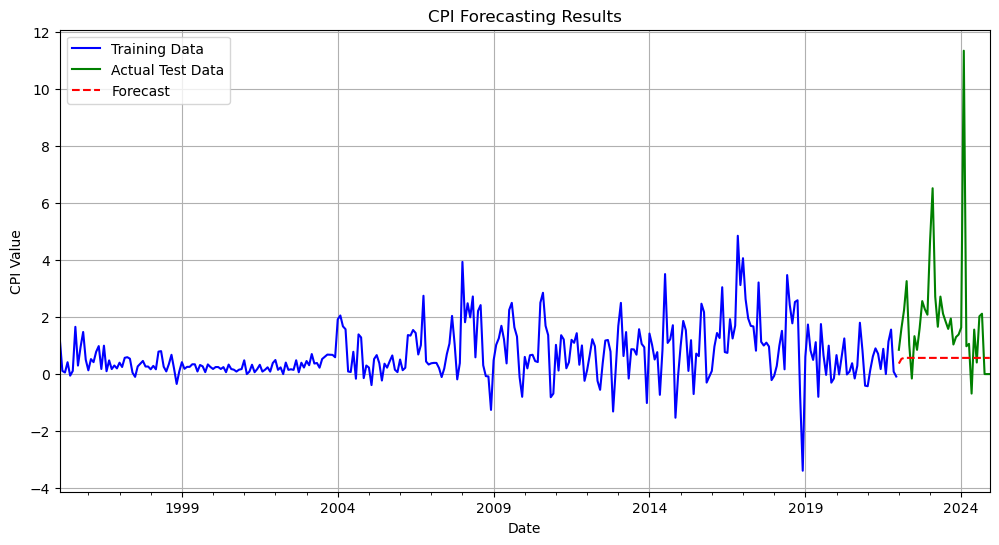


First few rows of results:
              Actual  Forecast     Error
Date                                    
2022-01-01  0.852152  0.367182  0.484969
2022-02-01  1.611443  0.534395  1.077048
2022-03-01  2.248159  0.567430  1.680729
2022-04-01  3.261785  0.569608  2.692177
2022-05-01  1.023852  0.568522  0.455330


In [3]:
import pmdarima as pm

# Test different d values with auto_arima on inflation rates
model = pm.auto_arima(
    combined_df["Inflation"],     # Use inflation rate instead of CPI
    d=None,                       # Let auto_arima determine d
    start_p=0, max_p=5,          # AR order
    start_q=0, max_q=5,          # MA order
    max_d=2,                      # Test up to 2nd difference
    seasonal=False,               # No seasonal component needed for inflation rates
    stepwise=True,               # Faster search
    trace=True,                  # Show AIC for each model
    error_action='ignore',
    suppress_warnings=True,
    information_criterion='aic'   # Use AIC for model selection
)

# Print comprehensive model results
print("\nBest Model Summary:")
print(model.summary())
print(f"\nOptimal ARIMA Order (p,d,q): {model.order}")
print(f"\nOptimal order of differencing (d): {model.order[1]}")

# Store the optimal order for later use
optimal_p, optimal_d, optimal_q = model.order


#-----------------------------------------------------------------------------

import numpy as np
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Step 1: Split CPI data (90% train / 10% test)
split_index = int(len(combined_df["Inflation"]) * 0.9)
train_cpi = combined_df["Inflation"].iloc[:split_index]
test_cpi = combined_df["Inflation"].iloc[split_index:]

# Step 2: Fit ARIMA on training data
model_arima = ARIMA(train_cpi, order=(2, 1, 1))  # Use optimal parameters from auto_arima
model_arima_fit = model_arima.fit()

# Step 3: Generate forecast
forecast_cpi = pd.Series(
    model_arima_fit.forecast(steps=len(test_cpi)),
    index=test_cpi.index,
    name='Forecast'
)

# Step 4: Calculate metrics
mae = mean_absolute_error(test_cpi, forecast_cpi)
rmse = np.sqrt(mean_squared_error(test_cpi, forecast_cpi))  # Manual RMSE calculation
mape = np.mean(np.abs((test_cpi - forecast_cpi) / test_cpi)) * 100  # MAPE calculation
r2 = r2_score(test_cpi, forecast_cpi)  # R-squared calculation
def smape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    numerator = np.abs(y_pred - y_true)

    mask = denominator != 0
    smape_vals = np.zeros_like(numerator)
    smape_vals[mask] = numerator[mask] / denominator[mask]

    return np.mean(smape_vals) * 100

smape_score = smape(test_cpi, forecast_cpi)


# Step 5: Print performance metrics
print("ARIMA(2,1,1) Performance Metrics:")
print(f"R-squared: {r2:.4f}")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAPE: {mape:.2f}%")
print(f"SMAPE: {smape_score:.2f}%")

# Step 6: Visualize results
plt.figure(figsize=(12, 6))
train_cpi.plot(label='Training Data', color='blue')
test_cpi.plot(label='Actual Test Data', color='green')
forecast_cpi.plot(label='Forecast', color='red', linestyle='--')
plt.title('CPI Forecasting Results')
plt.xlabel('Date')
plt.ylabel('CPI Value')
plt.legend()
plt.grid(True)
plt.show()

# Optional: Save forecasts to DataFrame
results_df = pd.DataFrame({
    'Actual': test_cpi,
    'Forecast': forecast_cpi,
    'Error': test_cpi - forecast_cpi
})
print("\nFirst few rows of results:")
print(results_df.head())


In [4]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import seaborn as sns



param_grid = [
    {"n_estimators": 100, "learning_rate": 0.01, "max_depth": 3, "subsample": 0.8, "colsample_bytree": 0.8},
    {"n_estimators": 200, "learning_rate": 0.01, "max_depth": 4, "subsample": 0.6, "colsample_bytree": 0.6},
    {"n_estimators": 300, "learning_rate": 0.05, "max_depth": 5, "subsample": 0.8, "colsample_bytree": 0.8},
    {"n_estimators": 150, "learning_rate": 0.1, "max_depth": 6, "subsample": 1.0, "colsample_bytree": 1.0},
    {"n_estimators": 100, "learning_rate": 0.2, "max_depth": 2, "subsample": 0.7, "colsample_bytree": 0.7},
    {"n_estimators": 250, "learning_rate": 0.03, "max_depth": 4, "subsample": 0.75, "colsample_bytree": 0.75},
    {"n_estimators": 200, "learning_rate": 0.01, "max_depth": 6, "subsample": 0.9, "colsample_bytree": 0.9},
]



features = ["US/EGP", "Value_Percent", "Value_in_M", "Dummy_Float", "Dummy_COVID", "Dummy_Ukraine"]

# Set target to raw inflation
target = "Inflation"
split_index = int(len(combined_df) * 0.9)

# Same 90/10 split as before
# Train-test split
train = combined_df.iloc[:split_index]
test = combined_df.iloc[split_index:]

X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

# Search across parameter grid
# Initialize best RMSE to infinity
best_rmse = float("inf")
best_model = None
best_params = None

for params in param_grid:
    model = XGBRegressor(objective="reg:squarederror", random_state=42, **params)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, preds))
    
    if rmse < best_rmse:
        best_rmse = rmse
        best_model = model
        best_params = params
        best_preds = preds

print("🔥 Best XGBoost Parameters:", best_params)
print(f"✅ Best RMSE on Inflation: {best_rmse:.4f}")

# Final evaluation
mae = mean_absolute_error(y_test, best_preds)
r2 = r2_score(y_test, best_preds)
mape = np.mean(np.abs((y_test - best_preds) / y_test)) * 100

print("\n📊 Standalone XGBoost Inflation Prediction:")
print(f"R²   : {r2:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {best_rmse:.4f}")
print(f"MAPE : {mape:.2f}%")


🔥 Best XGBoost Parameters: {'n_estimators': 200, 'learning_rate': 0.01, 'max_depth': 4, 'subsample': 0.6, 'colsample_bytree': 0.6}
✅ Best RMSE on Inflation: 2.3361

📊 Standalone XGBoost Inflation Prediction:
R²   : -0.2854
MAE  : 1.4196
RMSE : 2.3361
MAPE : inf%



🔧 Hybrid Model (Inflation) Performance:
R²   : -0.4274
MAE  : 1.5842
RMSE : 2.4618
MAPE : inf%


C:\Users\dode6\AppData\Local\Temp\ipykernel_18708\3646750135.py:72: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  plt.plot(test_cpi.index, hybrid_forecast, label="Hybrid Forecast", color="purple", linestyle=":")


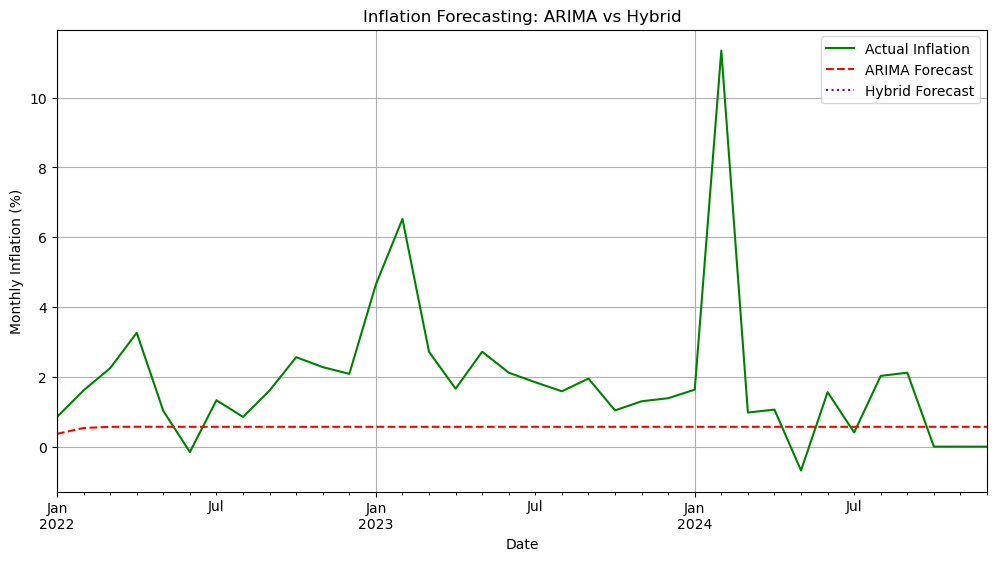

In [5]:
# Hybrid Model: Combine ARIMA and XGBoost

from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

# 1. Residuals
residuals_train = model_arima_fit.resid
residuals_test = test_cpi - forecast_cpi

# Combine residuals into one series (for storing in DF)
all_residuals = pd.concat([residuals_train, residuals_test], ignore_index=True)

# Drop first residual to match combined_df length after pct_change
all_residuals = all_residuals.iloc[1:]  # now both lengths = 358

# 2. Add to combined dataset
combined_df = combined_df.iloc[1:]  # Remove first row with NaN after pct_change
combined_df = combined_df.reset_index()
combined_df["ARIMA_resid"] = all_residuals.values

# 3. Train/test split
split_index = int(len(combined_df) * 0.9)
train = combined_df.iloc[:split_index]
test = combined_df.iloc[split_index:]

target_hybrid = "ARIMA_resid"

X_train = train[features]
y_train = train[target_hybrid]
X_test = test[features]
y_test = test[target_hybrid]

# 4. Train XGBoost
xgb_model = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=200,
    learning_rate=0.01,
    max_depth=4,
    subsample=0.6,
    colsample_bytree=0.6,
    random_state=42
)
xgb_model.fit(X_train, y_train)

# 5. Predict residuals
predicted_resid = xgb_model.predict(X_test)

# 6. Reconstruct final inflation forecast
hybrid_forecast = forecast_cpi.reset_index(drop=True) + predicted_resid
true_inflation = test_cpi.reset_index(drop=True)

# 7. Evaluate
mae = mean_absolute_error(true_inflation, hybrid_forecast)
rmse = np.sqrt(mean_squared_error(true_inflation, hybrid_forecast))  # ✅ Manual, version-safe
mape = np.mean(np.abs((true_inflation - hybrid_forecast) / true_inflation)) * 100
r2 = r2_score(true_inflation, hybrid_forecast)


# 8. Print performance metrics
print("\n🔧 Hybrid Model (Inflation) Performance:")
print(f"R²   : {r2:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"MAPE : {mape:.2f}%")

# Optional visualization
plt.figure(figsize=(12, 6))
test_cpi.plot(label="Actual Inflation", color="green")
forecast_cpi.plot(label="ARIMA Forecast", color="red", linestyle="--")
plt.plot(test_cpi.index, hybrid_forecast, label="Hybrid Forecast", color="purple", linestyle=":")
plt.title("Inflation Forecasting: ARIMA vs Hybrid")
plt.xlabel("Date")
plt.ylabel("Monthly Inflation (%)")
plt.legend()
plt.grid(True)
plt.show()


In [6]:
def print_observation_info_from_column(df, date_column="Date", name="DataFrame"):
    print(f"{name} — Number of observations: {len(df)}")
    print(f"{name} — First date: {pd.to_datetime(df[date_column]).min().strftime('%Y-%m-%d')}")
    print(f"{name} — Last date: {pd.to_datetime(df[date_column]).max().strftime('%Y-%m-%d')}")
    print("-" * 50)

# Example usage:
print_observation_info_from_column(combined_df, "Date", "Combined Dataset")


Combined Dataset — Number of observations: 358
Combined Dataset — First date: 1995-03-01
Combined Dataset — Last date: 2024-12-01
--------------------------------------------------


In [7]:
# fixed XGBoost params from 90/10 best
xgb_params = {
    'objective':'reg:squarederror',
    'n_estimators':200,
    'learning_rate':0.01,
    'max_depth':4,
    'subsample':0.6,
    'colsample_bytree':0.6,
    'random_state':42
}

for split in [0.8, 0.7]:
    idx = int(len(combined_df)*split)
    train_inf = combined_df["Inflation"].iloc[:idx]
    test_inf  = combined_df["Inflation"].iloc[idx:]

    # ARIMA(2,1,1)
    ar_mod = ARIMA(train_inf, order=(2,1,1)).fit()
    ar_fc  = ar_mod.forecast(steps=len(test_inf))
    print(f"\n=== Split {int(split*100)}/{100-int(split*100)} ARIMA ===")
    print("MAE:", round(mean_absolute_error(test_inf, ar_fc),4))
    print("RMSE:", round(np.sqrt(mean_squared_error(test_inf, ar_fc)),4))
    print("R2:", round(r2_score(test_inf, ar_fc),4))

    # XGBoost only
    dfr = combined_df.reset_index()
    tr = dfr.iloc[:idx]; te = dfr.iloc[idx:]
    Xtr, ytr = tr[features], tr["Inflation"]
    Xte, yte = te[features], te["Inflation"]

    xgb = XGBRegressor(**xgb_params).fit(Xtr, ytr)
    xgb_fc = xgb.predict(Xte)
    print(f"=== Split {int(split*100)}/{100-int(split*100)} XGB ===")
    print("MAE:", round(mean_absolute_error(yte, xgb_fc),4))
    print("RMSE:", round(np.sqrt(mean_squared_error(yte, xgb_fc)),4))
    print("R2:", round(r2_score(yte, xgb_fc),4))



=== Split 80/20 ARIMA ===
MAE: 1.0199
RMSE: 1.7028
R2: -0.0194
=== Split 80/20 XGB ===
MAE: 1.0144
RMSE: 1.7432
R2: -0.0683

=== Split 70/30 ARIMA ===
MAE: 1.0715
RMSE: 1.6993
R2: -0.0996
=== Split 70/30 XGB ===
MAE: 1.1686
RMSE: 1.7935
R2: -0.225


In [8]:
import itertools

arima_orders = [(1,1,0),(2,1,1),(3,1,0)]
xgb_grid = [
    {'n_estimators':100,'learning_rate':0.01,'max_depth':3,'subsample':0.8,'colsample_bytree':0.8},
    {'n_estimators':200,'learning_rate':0.01,'max_depth':4,'subsample':0.6,'colsample_bytree':0.6},
    {'n_estimators':300,'learning_rate':0.05,'max_depth':5,'subsample':0.8,'colsample_bytree':0.8}
]
results = []

for split in [0.9,0.8,0.7]:
    idx = int(len(combined_df)*split)
    train_inf = combined_df["Inflation"].iloc[:idx]
    test_inf  = combined_df["Inflation"].iloc[idx:]
    # ARIMA search
    best_ar = (None, np.inf)
    for order in arima_orders:
        m = ARIMA(train_inf,order=order).fit()
        fc = m.forecast(len(test_inf))
        rmse = np.sqrt(mean_squared_error(test_inf,fc))
        if rmse<best_ar[1]:
            best_ar=(order,rmse)
    # XGB search
    df_r = combined_df.reset_index()
    tr, te = df_r.iloc[:idx], df_r.iloc[idx:]
    best_x = (None,np.inf)
    for params in xgb_grid:
        model = XGBRegressor(objective='reg:squarederror',random_state=42,**params).fit(
            tr[features], tr["Inflation"])
        pred = model.predict(te[features])
        rmse = np.sqrt(mean_squared_error(te["Inflation"],pred))
        if rmse<best_x[1]:
            best_x=(params,rmse)
    results.append({
        "Split":f"{int(split*100)}/{100-int(split*100)}",
        "Best_ARIMA":best_ar[0],"RMSE_ARIMA":best_ar[1],
        "Best_XGB": best_x[0],"RMSE_XGB": best_x[1]
    })

print(pd.DataFrame(results))


   Split Best_ARIMA  RMSE_ARIMA  \
0  90/10  (2, 1, 1)    2.468260   
1  80/20  (2, 1, 1)    1.702830   
2  70/30  (2, 1, 1)    1.699269   

                                            Best_XGB  RMSE_XGB  
0  {'n_estimators': 200, 'learning_rate': 0.01, '...  2.354809  
1  {'n_estimators': 200, 'learning_rate': 0.01, '...  1.743155  
2  {'n_estimators': 100, 'learning_rate': 0.01, '...  1.792283  


In [15]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np, pandas as pd, itertools
from statsmodels.tsa.arima.model import ARIMA
from xgboost import XGBRegressor

# ----------------------------------------------------------
# helper to avoid MAPE = inf when true value is zero
# ----------------------------------------------------------
def safe_mape(y_true, y_pred):
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

# ----------------------------------------------------------
# grids (unchanged) ...
# ----------------------------------------------------------
p_range = range(0,5); d_range=[1]; q_range = range(0,4)
arima_orders = [(p,d,q) for p,d,q in itertools.product(p_range,d_range,q_range)]

n_estimators_vals = [100,200,300,500]
learning_rates    = [0.01,0.03,0.05,0.1]
max_depth_vals    = [3,4,5,6]
subsample_vals    = [0.6,0.8,1.0]
colsample_vals    = [0.6,0.8,1.0]

xgb_grid = [dict(n_estimators=n,learning_rate=eta,max_depth=md,
                 subsample=sub,colsample_bytree=col,
                 objective="reg:squarederror",random_state=42)
            for n,eta,md,sub,col
            in itertools.product(n_estimators_vals,learning_rates,
                                 max_depth_vals,subsample_vals,colsample_vals)]

splits   = [0.9,0.8,0.7]
features = ["US/EGP","Value_Percent","Value_in_M",
            "Dummy_Float","Dummy_COVID","Dummy_Ukraine"]

results  = []
for split in splits:
    idx       = int(len(combined_df)*split)
    train_inf = combined_df["Inflation"].iloc[:idx]
    test_inf  = combined_df["Inflation"].iloc[idx:]

    # ---------- ARIMA search ----------
    best_ar = {'order':None,'rmse':np.inf,'mae':None,'r2':None,'mape':None}
    for order in arima_orders:
        try:
            fm  = ARIMA(train_inf,order=order).fit()
            fc  = fm.forecast(len(test_inf))
        except:                # skip failures / non-invertible orders
            continue
        rmse = np.sqrt(mean_squared_error(test_inf,fc))
        if rmse < best_ar['rmse']:
            best_ar.update({
                'order':order,
                'rmse' :rmse,
                'mae'  :mean_absolute_error(test_inf,fc),
                'r2'   :r2_score(test_inf,fc),
                'mape': safe_mape(test_inf,fc)
            })

    # ---------- XGBoost search ----------
    df_r        = combined_df.reset_index(drop=True)
    tr_df,te_df = df_r.iloc[:idx], df_r.iloc[idx:]
    Xtr,ytr     = tr_df[features], tr_df["Inflation"]
    Xte,yte     = te_df[features], te_df["Inflation"]

    best_x = {'params':None,'rmse':np.inf,'mae':None,'r2':None,'mape':None}
    for params in xgb_grid:
        model = XGBRegressor(**params)
        model.fit(Xtr,ytr)
        preds = model.predict(Xte)
        rmse  = np.sqrt(mean_squared_error(yte,preds))
        if rmse < best_x['rmse']:
            best_x.update({
                'params':params,
                'rmse'  :rmse,
                'mae'   :mean_absolute_error(yte,preds),
                'r2'    :r2_score(yte,preds),
                'mape'  :safe_mape(yte,preds)
            })

    # ---------- store ----------
    split_label = f"{int(split*100)}/{round((1-split)*100)}"   # <-- fixed
    results.append({
        "Split"       : split_label,
        "Best_ARIMA"  : best_ar['order'],
        "RMSE_ARIMA"  : best_ar['rmse'],
        "MAE_ARIMA"   : best_ar['mae'],
        "R2_ARIMA"    : best_ar['r2'],
        "MAPE_ARIMA"  : best_ar['mape'],
        "Best_XGB"    : best_x['params'],
        "RMSE_XGB"    : best_x['rmse'],
        "MAE_XGB"     : best_x['mae'],
        "R2_XGB"      : best_x['r2'],
        "MAPE_XGB"    : best_x['mape']
    })

# summary table
results_df = pd.DataFrame(results)
print(results_df)


c:\Users\dode6\anaconda3\envs\econml\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\dode6\anaconda3\envs\econml\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
c:\Users\dode6\anaconda3\envs\econml\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\dode6\anaconda3\envs\econml\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
c:\Users

   Split Best_ARIMA  RMSE_ARIMA  MAE_ARIMA  R2_ARIMA  MAPE_ARIMA  \
0  90/10  (4, 1, 3)    2.441891   1.527925 -0.404464   77.250059   
1  80/20  (0, 1, 2)    1.691255   1.014289 -0.005615  485.546152   
2  70/30  (2, 1, 3)    1.680307   1.062368 -0.075242  286.064348   

                                            Best_XGB  RMSE_XGB   MAE_XGB  \
0  {'n_estimators': 500, 'learning_rate': 0.03, '...  2.085402  1.150598   
1  {'n_estimators': 300, 'learning_rate': 0.1, 'm...  1.538114  0.872431   
2  {'n_estimators': 100, 'learning_rate': 0.1, 'm...  1.670894  1.050025   

     R2_XGB    MAPE_XGB  
0 -0.024325   74.939507  
1  0.168254  416.287480  
2 -0.063228  294.049763  


In [31]:
# ----------------------------------------------------------
# 4) Evaluate Hybrid (ARIMA + XGB residual) for each split
# ----------------------------------------------------------
hybrid_rows = []

for row in results:                       # row already contains best orders / params
    split_label   = row["Split"]
    p,d,q         = row["Best_ARIMA"]     # tuple, e.g. (4,1,3)
    xgb_params    = row["Best_XGB"]       # dict of hyper-params

    # --- rebuild the train / test partitions ----------------
    split_ratio   = int(split_label.split('/')[0]) / 100
    idx           = int(len(combined_df) * split_ratio)

    tr_df, te_df  = combined_df.iloc[:idx], combined_df.iloc[idx:]

    # --- 1. Fit ARIMA on training inflation -----------------
    ar_fit = ARIMA(tr_df["Inflation"], order=(p,d,q)).fit()

    # in-sample residuals (drop first d NaNs from differencing)
    resid_train = tr_df["Inflation"].iloc[d:] - ar_fit.fittedvalues
    resid_train = resid_train.reset_index(drop=True)  # align with Xtr
    resid_train = resid_train.iloc[d:]               # drop first d NaNs

    # --- 2. Fit XGB on those residuals ----------------------
    Xtr = tr_df.iloc[d:][features]        # align with resid_train length
    Xte = te_df[features]

   
    print("------------------------------------------------------")
    print(f"Features shape: {Xtr.shape}")
    print(f"Residuals shape: {resid_train.shape}")
    print("------------------------------------------------------")

    # Make sure residuals is a proper Series/array
    resid_train = pd.Series(resid_train)  # Convert
    
    xgb_resid = XGBRegressor(**xgb_params)
    xgb_resid.fit(Xtr, resid_train)

    # --- 3. Forecast ---------------------------------------
    fc_arima  = ar_fit.forecast(len(te_df))            # base forecast
    fc_resid  = xgb_resid.predict(Xte)                 # residual forecast
    fc_hybrid = fc_arima.reset_index(drop=True) + fc_resid

    # --- 4. Metrics ----------------------------------------
    true      = te_df["Inflation"].reset_index(drop=True)
    rmse_h    = np.sqrt(mean_squared_error(true, fc_hybrid))
    mae_h     = mean_absolute_error(true, fc_hybrid)
    r2_h      = r2_score(true, fc_hybrid)
    mape_h    = safe_mape(true, fc_hybrid)

    hybrid_rows.append({
        "Split"       : split_label,
        "ARIMA_order" : (p,d,q),
        "XGB_params"  : {k:xgb_params[k] for k in
                         ["n_estimators","learning_rate","max_depth"]},
        "RMSE_Hybrid" : rmse_h,
        "MAE_Hybrid"  : mae_h,
        "R2_Hybrid"   : r2_h,
        "MAPE_Hybrid" : mape_h
    })

hybrid_df = pd.DataFrame(hybrid_rows)
print("\n=== Hybrid results ===")
print(hybrid_df)


c:\Users\dode6\anaconda3\envs\econml\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


------------------------------------------------------
Features shape: (321, 6)
Residuals shape: (321,)
------------------------------------------------------
------------------------------------------------------
Features shape: (285, 6)
Residuals shape: (285,)
------------------------------------------------------


c:\Users\dode6\anaconda3\envs\econml\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


------------------------------------------------------
Features shape: (249, 6)
Residuals shape: (249,)
------------------------------------------------------

=== Hybrid results ===
   Split ARIMA_order                                         XGB_params  \
0  90/10   (4, 1, 3)  {'n_estimators': 500, 'learning_rate': 0.03, '...   
1  80/20   (0, 1, 2)  {'n_estimators': 300, 'learning_rate': 0.1, 'm...   
2  70/30   (2, 1, 3)  {'n_estimators': 100, 'learning_rate': 0.1, 'm...   

   RMSE_Hybrid  MAE_Hybrid  R2_Hybrid  MAPE_Hybrid  
0     2.230850    1.325318  -0.172193    72.506712  
1     1.605133    0.927555   0.094194   375.272135  
2     1.680826    1.085859  -0.075906   344.522295  


In [22]:
print(results)

[{'Split': '90/10', 'Best_ARIMA': (4, 1, 3), 'RMSE_ARIMA': 2.4418909092945524, 'MAE_ARIMA': 1.5279249193603386, 'R2_ARIMA': -0.4044639337732847, 'MAPE_ARIMA': 77.250058813322, 'Best_XGB': {'n_estimators': 500, 'learning_rate': 0.03, 'max_depth': 6, 'subsample': 0.6, 'colsample_bytree': 0.6, 'objective': 'reg:squarederror', 'random_state': 42}, 'RMSE_XGB': 2.0854022277244217, 'MAE_XGB': 1.1505983251831138, 'R2_XGB': -0.02432492660158392, 'MAPE_XGB': 74.93950692970115}, {'Split': '80/20', 'Best_ARIMA': (0, 1, 2), 'RMSE_ARIMA': 1.6912548692473126, 'MAE_ARIMA': 1.0142890756729726, 'R2_ARIMA': -0.0056145539012992796, 'MAPE_ARIMA': 485.5461521384754, 'Best_XGB': {'n_estimators': 300, 'learning_rate': 0.1, 'max_depth': 5, 'subsample': 1.0, 'colsample_bytree': 0.6, 'objective': 'reg:squarederror', 'random_state': 42}, 'RMSE_XGB': 1.5381143578536718, 'MAE_XGB': 0.8724310766327081, 'R2_XGB': 0.168254073547202, 'MAPE_XGB': 416.2874796719816}, {'Split': '70/30', 'Best_ARIMA': (2, 1, 3), 'RMSE_ARIM

In [ ]:
# ================================================================
#  Hybrid: keep previously-selected ARIMA orders, re-tune XGB-resid
#  (expects `results`  or  `results_df` from your earlier loop)
# ================================================================
import numpy as np, pandas as pd, itertools
from statsmodels.tsa.arima.model import ARIMA
from xgboost import XGBRegressor
from sklearn.metrics import (mean_squared_error,
                             mean_absolute_error, r2_score)

def safe_mape(y_true, y_pred):
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

# -------- full 576-combo XGB grid (same as before) --------------
n_estimators_vals = [100,200,300,500]
learning_rates    = [0.01,0.03,0.05,0.1]
max_depth_vals    = [3,4,5,6]
subsample_vals    = [0.6,0.8,1.0]
colsample_vals    = [0.6,0.8,1.0]

xgb_grid = [dict(n_estimators=n,learning_rate=eta,max_depth=md,
                 subsample=sub,colsample_bytree=col,
                 objective="reg:squarederror",random_state=42)
            for n,eta,md,sub,col
            in itertools.product(n_estimators_vals,learning_rates,
                                 max_depth_vals,subsample_vals,colsample_vals)]

features = ["US/EGP","Value_Percent","Value_in_M",
            "Dummy_Float","Dummy_COVID","Dummy_Ukraine"]

hybrid_rows = []

# ---------------------------------------------------------------
# If your earlier object is a DataFrame, convert to dict-rows
# ---------------------------------------------------------------
if isinstance(results, list):
    rows_iter = results
else:                                  # results_df DataFrame
    rows_iter = results_df.to_dict('records')

for row in rows_iter:
    split_label = row["Split"]                     # e.g. "90/10"
    p,d,q       = row["Best_ARIMA"]               # <- keep this order
    split_ratio = int(split_label.split('/')[0]) / 100
    idx         = int(len(combined_df) * split_ratio)

    tr_df, te_df = combined_df.iloc[:idx], combined_df.iloc[idx:]
    y_train, y_test = tr_df["Inflation"], te_df["Inflation"]

    # 1. Fit **the chosen** ARIMA order
    ar_fit = ARIMA(y_train, order=(p,d,q)).fit()

    # residuals for XGB training  (align after differencing)
    resid_train = y_train.iloc[d:] - ar_fit.fittedvalues
    resid_train = resid_train.reset_index(drop=True)  # align with Xtr
    resid_train = resid_train.iloc[d:]               # drop first d NaNs
    Xtr_resid   = tr_df.iloc[d:][features]
    Xte         = te_df[features]
    fc_ar_test  = ar_fit.forecast(len(y_test))        # base forecast

    # 2. Grid-search XGBoost on residuals
    best_x = {'params':None,'rmse':np.inf,'mae':None,'r2':None,'mape':None}
    for prm in xgb_grid:
        mdl = XGBRegressor(**prm).fit(Xtr_resid, resid_train)
        pred_resid = mdl.predict(Xte)

        fc_hybrid = fc_ar_test.reset_index(drop=True) + pred_resid
        true      = y_test.reset_index(drop=True)
        rmse_h    = np.sqrt(mean_squared_error(true, fc_hybrid))

        if rmse_h < best_x['rmse']:
            best_x.update({
                'params':prm,
                'rmse' :rmse_h,
                'mae'  :mean_absolute_error(true, fc_hybrid),
                'r2'   :r2_score(true, fc_hybrid),
                'mape': safe_mape(true, fc_hybrid)
            })

    # 3. Store results
    hybrid_rows.append({
        "Split"        : split_label,
        "ARIMA_order"  : (p,d,q),
        "XGB_resid"    : {k:best_x['params'][k] for k in
                          ['n_estimators','learning_rate','max_depth',
                           'subsample','colsample_bytree']},
        "RMSE_Hybrid"  : best_x['rmse'],
        "MAE_Hybrid"   : best_x['mae'],
        "R2_Hybrid"    : best_x['r2'],
        "MAPE_Hybrid"  : best_x['mape']
    })


hybrid_df = pd.DataFrame(hybrid_rows)
lol = hybrid_df["XGB_resid"].apply(lambda x: x['n_estimators'])
print("\n=== Hybrid results (re-tuned XGB) ===")
print(lol)
print("\n=== Hybrid results (using prior ARIMA orders) ===")
print(hybrid_df)


c:\Users\dode6\anaconda3\envs\econml\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\dode6\anaconda3\envs\econml\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "



=== Hybrid results (using prior ARIMA orders) ===
   Split ARIMA_order                                          XGB_resid  \
0  90/10   (4, 1, 3)  {'n_estimators': 200, 'learning_rate': 0.1, 'm...   
1  80/20   (0, 1, 2)  {'n_estimators': 200, 'learning_rate': 0.1, 'm...   
2  70/30   (2, 1, 3)  {'n_estimators': 100, 'learning_rate': 0.1, 'm...   

   RMSE_Hybrid  MAE_Hybrid  R2_Hybrid  MAPE_Hybrid  
0     2.175268    1.259878  -0.114509    72.834983  
1     1.557013    0.903535   0.147690   416.374037  
2     1.587710    1.022456   0.040001   420.903498  


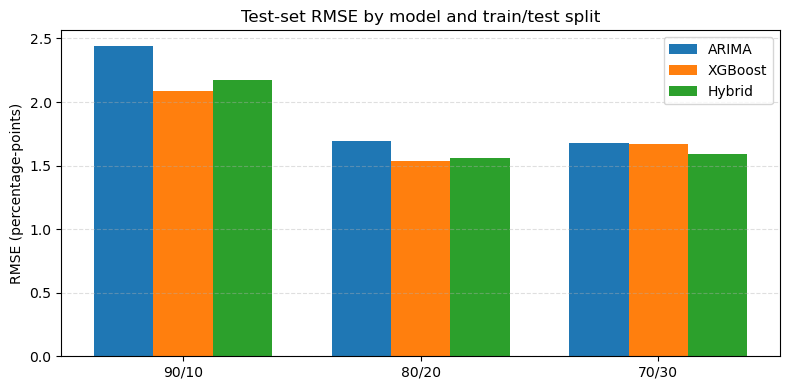

In [39]:
import matplotlib.pyplot as plt
import numpy as np

# --- data for plot ------------------------------------------------
splits        = tbl["Split"]
x_idx         = np.arange(len(splits))          # bar positions
width         = 0.25

fig, ax = plt.subplots(figsize=(8,4))
ax.bar(x_idx - width, tbl["RMSE_ARIMA"],  width, label="ARIMA")
ax.bar(x_idx,         tbl["RMSE_XGB"],    width, label="XGBoost")
ax.bar(x_idx + width, tbl["RMSE_Hybrid"], width, label="Hybrid")

ax.set_xticks(x_idx)
ax.set_xticklabels(splits)
ax.set_ylabel("RMSE (percentage-points)")
ax.set_title("Test-set RMSE by model and train/test split")
ax.legend()
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


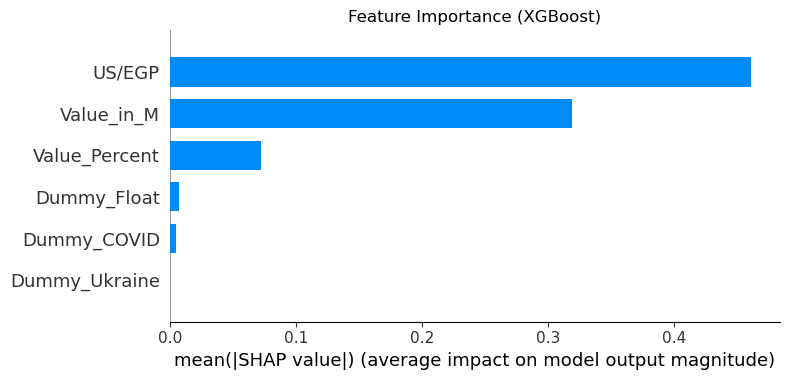

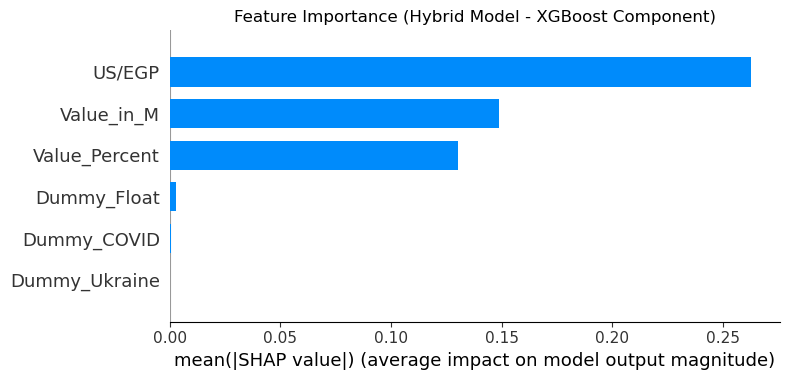

<Figure size 1000x600 with 0 Axes>

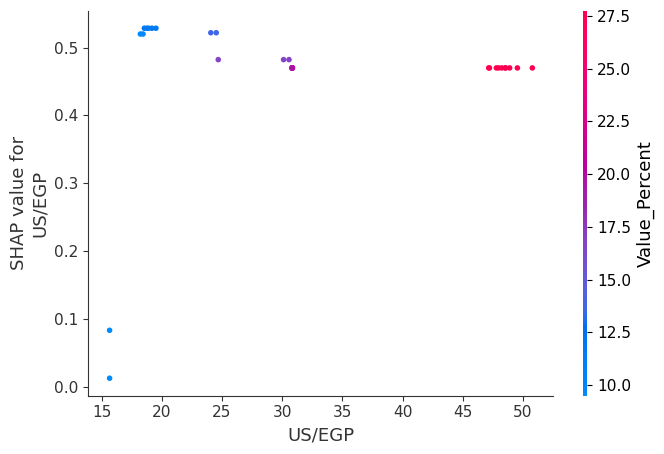

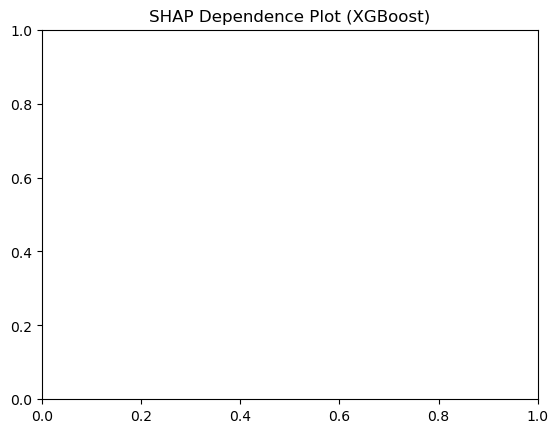

<Figure size 1000x600 with 0 Axes>

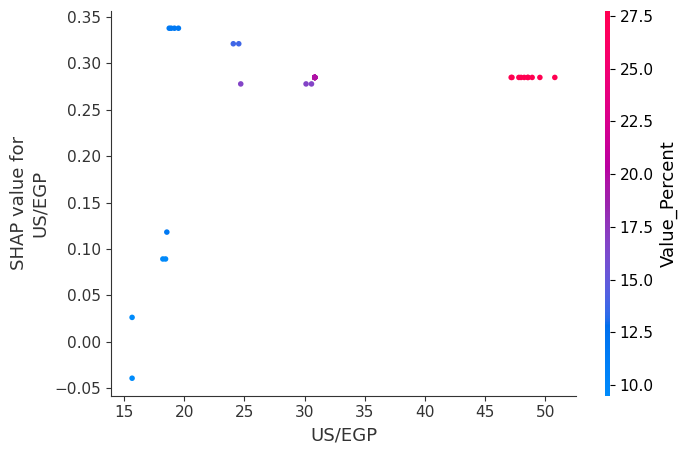

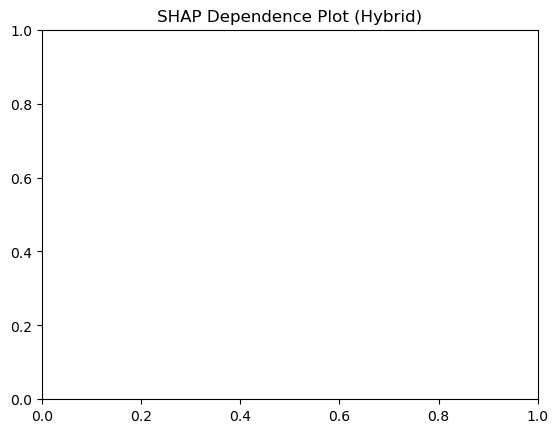


XGBoost SHAP Feature Importance:
         Feature  Importance
0         US/EGP    0.461249
2     Value_in_M    0.319612
1  Value_Percent    0.072584
3    Dummy_Float    0.007209
4    Dummy_COVID    0.004754
5  Dummy_Ukraine    0.000000

Hybrid SHAP Feature Importance:
         Feature  Importance
0         US/EGP    0.262554
2     Value_in_M    0.148878
1  Value_Percent    0.130204
3    Dummy_Float    0.002976
4    Dummy_COVID    0.000369
5  Dummy_Ukraine    0.000000


In [40]:
import shap
import matplotlib.pyplot as plt

# 1. XGBoost SHAP Analysis
# ------------------------
# Create explainer for standalone XGBoost
explainer_xgb = shap.TreeExplainer(best_model)
shap_values_xgb = explainer_xgb.shap_values(X_test)

# Plot XGBoost SHAP summary
plt.figure(figsize=(10,6))
shap.summary_plot(shap_values_xgb, X_test, plot_type="bar", 
                 show=False, feature_names=features)
plt.title("Feature Importance (XGBoost)")
plt.tight_layout()
plt.show()

# 2. Hybrid Model SHAP Analysis
# ----------------------------
# Create explainer for XGBoost part of hybrid
explainer_hybrid = shap.TreeExplainer(xgb_model)  # xgb_model from hybrid
shap_values_hybrid = explainer_hybrid.shap_values(X_test)

# Plot Hybrid SHAP summary
plt.figure(figsize=(10,6))
shap.summary_plot(shap_values_hybrid, X_test, plot_type="bar", 
                 show=False, feature_names=features)
plt.title("Feature Importance (Hybrid Model - XGBoost Component)")
plt.tight_layout()
plt.show()

# 3. Detailed SHAP Dependencies
# ----------------------------
# For most important feature in XGBoost
plt.figure(figsize=(10,6))
shap.dependence_plot(0, shap_values_xgb, X_test, feature_names=features)
plt.title("SHAP Dependence Plot (XGBoost)")
plt.show()

# For most important feature in Hybrid
plt.figure(figsize=(10,6))
shap.dependence_plot(0, shap_values_hybrid, X_test, feature_names=features)
plt.title("SHAP Dependence Plot (Hybrid)")
plt.show()

# 4. Save SHAP values and importances
# ---------------------------------
shap_importance_xgb = pd.DataFrame({
    'Feature': features,
    'Importance': np.abs(shap_values_xgb).mean(0)
})
shap_importance_hybrid = pd.DataFrame({
    'Feature': features,
    'Importance': np.abs(shap_values_hybrid).mean(0)
})

print("\nXGBoost SHAP Feature Importance:")
print(shap_importance_xgb.sort_values('Importance', ascending=False))
print("\nHybrid SHAP Feature Importance:")
print(shap_importance_hybrid.sort_values('Importance', ascending=False))

In [37]:
n_estimator = hybrid_df["XGB_resid"].apply(lambda x: x['n_estimators'])
learning_rates = hybrid_df["XGB_resid"].apply(lambda x: x['learning_rate'])
max_depth = hybrid_df["XGB_resid"].apply(lambda x: x['max_depth'])
subsample = hybrid_df["XGB_resid"].apply(lambda x: x['subsample'])
colsample_bytree = hybrid_df["XGB_resid"].apply(lambda x: x['colsample_bytree'])

print("\n=== Hybrid results (re-tuned XGB) ===")
print(n_estimator)
print(learning_rates)
print(max_depth)
print(subsample)
print(colsample_bytree)


=== Hybrid results (re-tuned XGB) ===
0    200
1    200
2    100
Name: XGB_resid, dtype: int64
0    0.1
1    0.1
2    0.1
Name: XGB_resid, dtype: float64
0    6
1    5
2    3
Name: XGB_resid, dtype: int64
0    0.6
1    0.6
2    0.6
Name: XGB_resid, dtype: float64
0    0.6
1    0.6
2    0.6
Name: XGB_resid, dtype: float64


In [ ]:
import itertools
from statsmodels.tsa.arima.model import ARIMA
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
import numpy as np
import pandas as pd

# -------------------------------------------------------------------
# 1) Generate a richer ARIMA grid  (p = 0–4, d = 1, q = 0–3)
# -------------------------------------------------------------------
p_range = range(0, 5)      # 0,1,2,3,4
d_range = [1]              # keep differencing fixed (already differenced once)
q_range = range(0, 4)      # 0,1,2,3
arima_orders = [(p, d, q) for p, d, q in itertools.product(p_range, d_range, q_range)]

# -------------------------------------------------------------------
# 2) Generate a richer XGBoost grid
# -------------------------------------------------------------------
n_estimators_vals = [100, 200, 300, 500]
learning_rates    = [0.01, 0.03, 0.05, 0.1]
max_depth_vals    = [3, 4, 5, 6]
subsample_vals    = [0.6, 0.8, 1.0]
colsample_vals    = [0.6, 0.8, 1.0]

xgb_grid = [
    dict(
        n_estimators=n, learning_rate=eta, max_depth=md,
        subsample=sub, colsample_bytree=col,
        objective="reg:squarederror", random_state=42
    )
    for n, eta, md, sub, col
    in itertools.product(n_estimators_vals, learning_rates,
                         max_depth_vals, subsample_vals, colsample_vals)
]

# -----------------------------------------
# 3) Search on 90/10, 80/20, 70/30 splits
# -----------------------------------------
splits = [0.9, 0.8, 0.7]
features = ["US/EGP", "Value_Percent", "Value_in_M", "Dummy_Float", "Dummy_COVID", "Dummy_Ukraine"]

results = []
for split in splits:
    idx = int(len(combined_df) * split)
    train_inf = combined_df["Inflation"].iloc[:idx]
    test_inf  = combined_df["Inflation"].iloc[idx:]

    # ----- ARIMA search -----
    best_ar = {'order': None, 'rmse': np.inf, 'mae': None, 'r2': None}
    for order in arima_orders:
        try:
            model = ARIMA(train_inf, order=order).fit()
        except:
            continue  # skip non-invertible models
        fc = model.forecast(len(test_inf))
        rmse = np.sqrt(mean_squared_error(test_inf, fc))
        if rmse < best_ar['rmse']:
            best_ar.update({
                'order': order,
                'rmse' : rmse,
                'mae'  : mean_absolute_error(test, fc),
                'r2'   : r2_score(test, fc)
            })


    # ----- XGBoost search -----
    df_r = combined_df.reset_index(drop=True)
    tr_df, te_df = df_r.iloc[:idx], df_r.iloc[idx:]
    Xtr, ytr = tr_df[features], tr_df["Inflation"]
    Xte, yte = te_df[features], te_df["Inflation"]

    best_x = {'params': None, 'rmse': np.inf, 'mae': None, 'r2': None}
    for params in xgb_grid:
        model = XGBRegressor(**params)
        model.fit(Xtr, ytr)
        preds = model.predict(Xte)
        rmse = np.sqrt(mean_squared_error(yte, preds))
        if rmse < best_x['rmse']:
            best_x.update({
                'params': params,
                'rmse'  : rmse,
                'mae'   : mean_absolute_error(yte, preds),
                'r2'    : r2_score(yte, preds)
            })

    results.append({
        "Split": f"{int(split*100)}/{int((1-split)*100)}",
        "Best_ARIMA": best_ar[0], "RMSE_ARIMA": best_ar[1],
        "Best_XGB": best_x[0],   "RMSE_XGB":  best_x[1]
    })

# Show summary
results_df = pd.DataFrame(results)
print(results_df)


c:\Users\dode6\anaconda3\envs\econml\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\dode6\anaconda3\envs\econml\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
c:\Users\dode6\anaconda3\envs\econml\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\dode6\anaconda3\envs\econml\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
c:\Users

   Split Best_ARIMA  RMSE_ARIMA  \
0   90/9  (4, 1, 3)    2.385494   
1  80/19  (0, 1, 2)    1.680759   
2  70/30  (4, 1, 3)    1.680843   

                                            Best_XGB  RMSE_XGB  
0  {'n_estimators': 500, 'learning_rate': 0.1, 'm...  2.047338  
1  {'n_estimators': 500, 'learning_rate': 0.1, 'm...  1.523019  
2  {'n_estimators': 100, 'learning_rate': 0.1, 'm...  1.660643  


In [ ]:
# Assuming you stored `baseline_df` and this grid-output in `grid_df`
comparison = baseline_df.merge(pd.DataFrame(results), on="Split", how="inner")
print(comparison)


In [ ]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

hybrid_res = []
for entry in results:
    sp = entry["Split"]
    split = int(sp.split("/")[0])/100
    idx = int(len(combined_df)*split)
    tr = combined_df.iloc[:idx]
    te = combined_df.iloc[idx:]
    # best ARIMAa
    ord = entry["Best_ARIMA"]
    am = ARIMA(tr["Inflation"],order=ord).fit()
    fc_ar = am.forecast(len(te))
    # residuals
    resid = te["Inflation"].reset_index(drop=True) - fc_ar.reset_index(drop=True)
    # best XGB on residuals
    xparams = entry["Best_XGB"]
    xmod = XGBRegressor(objective='reg:squarederror',random_state=42,**xparams).fit(
        tr[features], tr["Inflation"]  # note: retraining on Inflation, or you want Resid? use resid here
    )
    # if on residuals:
    xmod = XGBRegressor(objective='reg:squarederror',random_state=42,**xparams).fit(
        tr[features], (tr["Inflation"]-ARIMA(tr["Inflation"],order=ord).fit()
                       .forecast(steps=len(tr))).reset_index(drop=True)
    )
    pred_res = xmod.predict(te[features])
    # hybrid
    hybrid_fc = fc_ar.reset_index(drop=True) + pred_res
    true = te["Inflation"].reset_index(drop=True)
    hybrid_res.append({
        "Split":sp,
        "MAE":mean_absolute_error(true,hybrid_fc),
        "RMSE":np.sqrt(mean_squared_error(true,hybrid_fc)),
        "R2":r2_score(true,hybrid_fc)
    })

print(pd.DataFrame(hybrid_res))


In [14]:
print(model_arima_fit.summary())

                               SARIMAX Results                                
Dep. Variable:              Inflation   No. Observations:                  323
Model:                 ARIMA(2, 1, 1)   Log Likelihood                -396.414
Date:                Mon, 19 May 2025   AIC                            800.828
Time:                        22:56:01   BIC                            815.927
Sample:                    02-01-1995   HQIC                           806.856
                         - 12-01-2021                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3486      0.046      7.596      0.000       0.259       0.439
ar.L2         -0.0559      0.051     -1.087      0.277      -0.157       0.045
ma.L1         -0.9479      0.020    -47.614      0.0

In [38]:
# -------------------------------------------------------------
# Merge single-model and hybrid metrics into one tidy table
# -------------------------------------------------------------
tbl = (results_df[["Split",
                   "RMSE_ARIMA","MAE_ARIMA","R2_ARIMA",
                   "RMSE_XGB","MAE_XGB","R2_XGB"]]
       .merge(hybrid_df[["Split",
                         "RMSE_Hybrid","MAE_Hybrid","R2_Hybrid"]],
              on="Split", how="left"))

# Nicely formatted view
print("\n=== Model-comparison table (test-set metrics) ===")
print(tbl.to_string(index=False))

# Optional: save to CSV for thesis appendix
tbl.to_csv("model_comparison_metrics.csv", index=False)



=== Model-comparison table (test-set metrics) ===
Split  RMSE_ARIMA  MAE_ARIMA  R2_ARIMA  RMSE_XGB  MAE_XGB    R2_XGB  RMSE_Hybrid  MAE_Hybrid  R2_Hybrid
90/10    2.441891   1.527925 -0.404464  2.085402 1.150598 -0.024325     2.175268    1.259878  -0.114509
80/20    1.691255   1.014289 -0.005615  1.538114 0.872431  0.168254     1.557013    0.903535   0.147690
70/30    1.680307   1.062368 -0.075242  1.670894 1.050025 -0.063228     1.587710    1.022456   0.040001
